<a href="https://colab.research.google.com/github/BrittanyMcGuire1/churn_project/blob/master/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction
## WGU Computer Science Capstone
### Brittany McGuire

This notebook builds a machine learning model to predict customer churn
for a telecommunications company using the IBM Telco Customer Churn dataset.
The project follows the CRISP-DM methodology and uses logistic regression
to predict which customers are at high risk of canceling their service.

**Dataset:** IBM Telco Customer Churn (Kaggle)
**Algorithm:** Logistic Regression
**Libraries:** Pandas, Scikit-learn, Matplotlib, Seaborn, Plotly, ipywidgets
**Goal:** Reduce customer churn rate from 25% to below 15%
**Methodology:** CRISP-DM

## Section 1: Library Setup
This section imports all the Python libraries needed for the project.
These libraries handle data processing, machine learning, visualization,
and the interactive dashboard.

In [1]:
# Install any libraries not pre-installed in Colab
!pip install scikit-learn -q

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Section 2: Data Upload and Exploration
### CRISP-DM Phase 2: Data Understanding

In this section we upload the IBM Telco Customer Churn dataset and explore
its structure. The dataset contains 7,043 customer records and 21 columns
covering billing information, contract details, service usage, and whether
each customer churned. Understanding the data before modeling helps identify
issues that need to be addressed during preparation.

In [2]:
# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset into a dataframe
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic exploration
print("Dataset Shape:", df_raw.shape)
print()
print("First 5 rows:")
print(df_raw.head())
print()
print("Column Data Types:")
print(df_raw.dtypes)
print()
print("Missing Values:")
print(df_raw.isnull().sum())

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4             

### Section 2.1: Exploratory Data Analysis
Before cleaning the data we will visualize key patterns to understand
what the data looks like and identify relationships between variables
and churn.

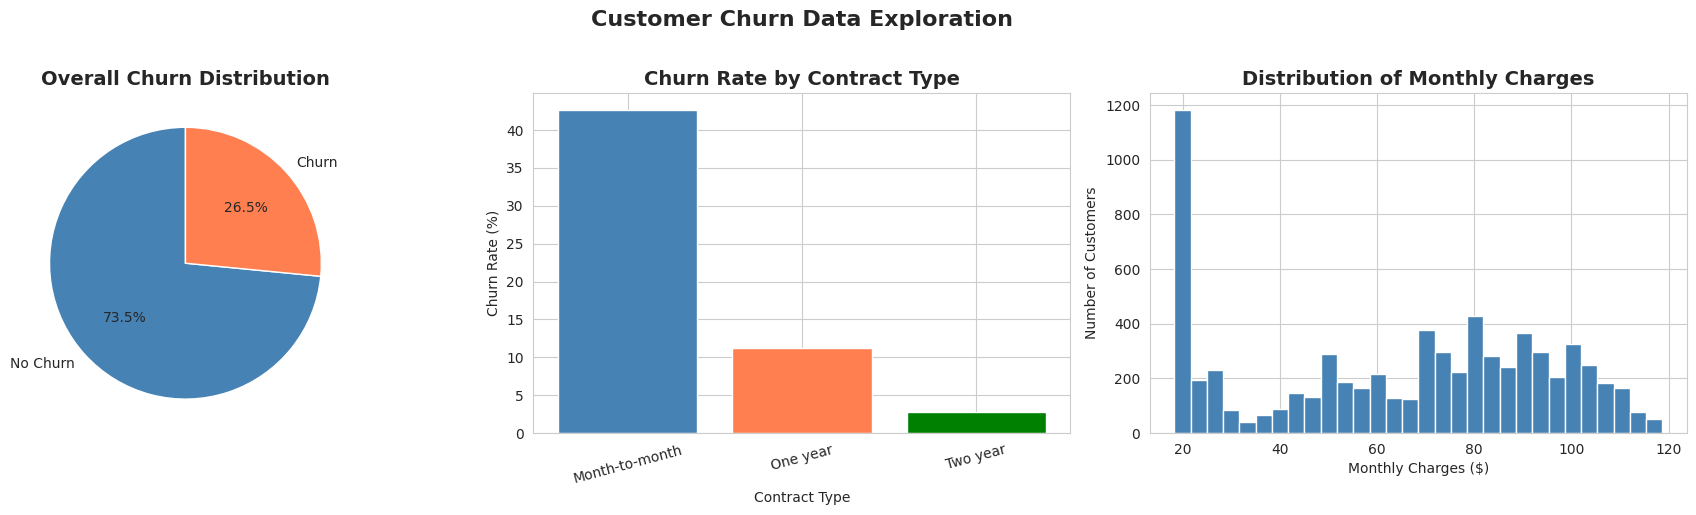

Exploration charts saved successfully


In [3]:
# Set the visual style for all charts
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Overall churn distribution
churn_counts = df_raw['Churn'].value_counts()
axes[0].pie(churn_counts,
            labels=['No Churn', 'Churn'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'],
            startangle=90)
axes[0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')

# Chart 2: Churn rate by contract type
contract_churn = df_raw.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']
axes[1].bar(contract_churn['Contract'],
            contract_churn['Churn Rate'],
            color=['steelblue', 'coral', 'green'])
axes[1].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

# Chart 3: Distribution of monthly charges
axes[2].hist(df_raw['MonthlyCharges'],
             bins=30,
             color='steelblue',
             edgecolor='white')
axes[2].set_title('Distribution of Monthly Charges',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Monthly Charges ($)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('Customer Churn Data Exploration',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exploration_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("Exploration charts saved successfully")

### Section 2.2: Key Findings from Data Exploration

**Chart 1 - Overall Churn Distribution:**
26.5% of customers churned which aligns with the 25% churn rate
identified in the business problem. This confirms the organizational
need for a predictive solution.

**Chart 2 - Churn Rate by Contract Type:**
Month-to-month customers churn at approximately 43% compared to
11% for one year contracts and less than 3% for two year contracts.
Contract type is clearly the strongest predictor of churn in this dataset.

**Chart 3 - Distribution of Monthly Charges:**
Monthly charges range from approximately $20 to $120 with concentrations
at the lower end around $20 for basic plans and between $70 and $100
for premium plans. Higher monthly charges are associated with higher
churn risk.

These findings support the project hypothesis that contract type and
monthly charges are key predictors of customer churn.

## Section 3: Data Cleaning and Preparation
### CRISP-DM Phase 3: Data Preparation

In this section we clean and prepare the raw dataset for use by the
logistic regression algorithm. The following steps are performed:

1. Fix the TotalCharges column by converting blank values to zero
2. Convert the Churn column from Yes/No text to 1/0 numbers
3. Remove the customerID column which has no predictive value
4. Apply one-hot encoding to convert text columns into numbers
5. Split the data into 80% training and 20% testing

This is often the most important phase of any machine learning project
because the quality of the data directly affects the quality of predictions.

In [5]:
# Make a copy of the raw data so we always have the original
df = df_raw.copy()

# Show data types before cleaning
print("BEFORE CLEANING:")
print("TotalCharges data type:", df['TotalCharges'].dtype)
print("Churn sample values:", df['Churn'].unique())
print("Dataset shape:", df.shape)
print()

# Step 1: Fix TotalCharges
# Convert blank strings to NaN then fill with zero
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 2: Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Step 3: Drop customerID
df = df.drop('customerID', axis=1)

# Step 4: Apply one-hot encoding to all remaining text columns
df = pd.get_dummies(df, drop_first=True)

# Save cleaned dataset
df.to_csv('telco_cleaned.csv', index=False)

# Show data types after cleaning
print("AFTER CLEANING:")
print("TotalCharges data type:", df['TotalCharges'].dtype)
print("Churn sample values:", df['Churn'].unique())
print("Dataset shape:", df.shape)
print()
print("First 5 rows of cleaned data:")
print(df.head())
print()
print("Cleaning complete. Cleaned dataset saved as telco_cleaned.csv")

BEFORE CLEANING:
TotalCharges data type: object
Churn sample values: ['No' 'Yes']
Dataset shape: (7043, 21)

AFTER CLEANING:
TotalCharges data type: float64
Churn sample values: [0 1]
Dataset shape: (7043, 31)

First 5 rows of cleaned data:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False